Saved: robustness_figures\figure_all_in_one_robustness.png


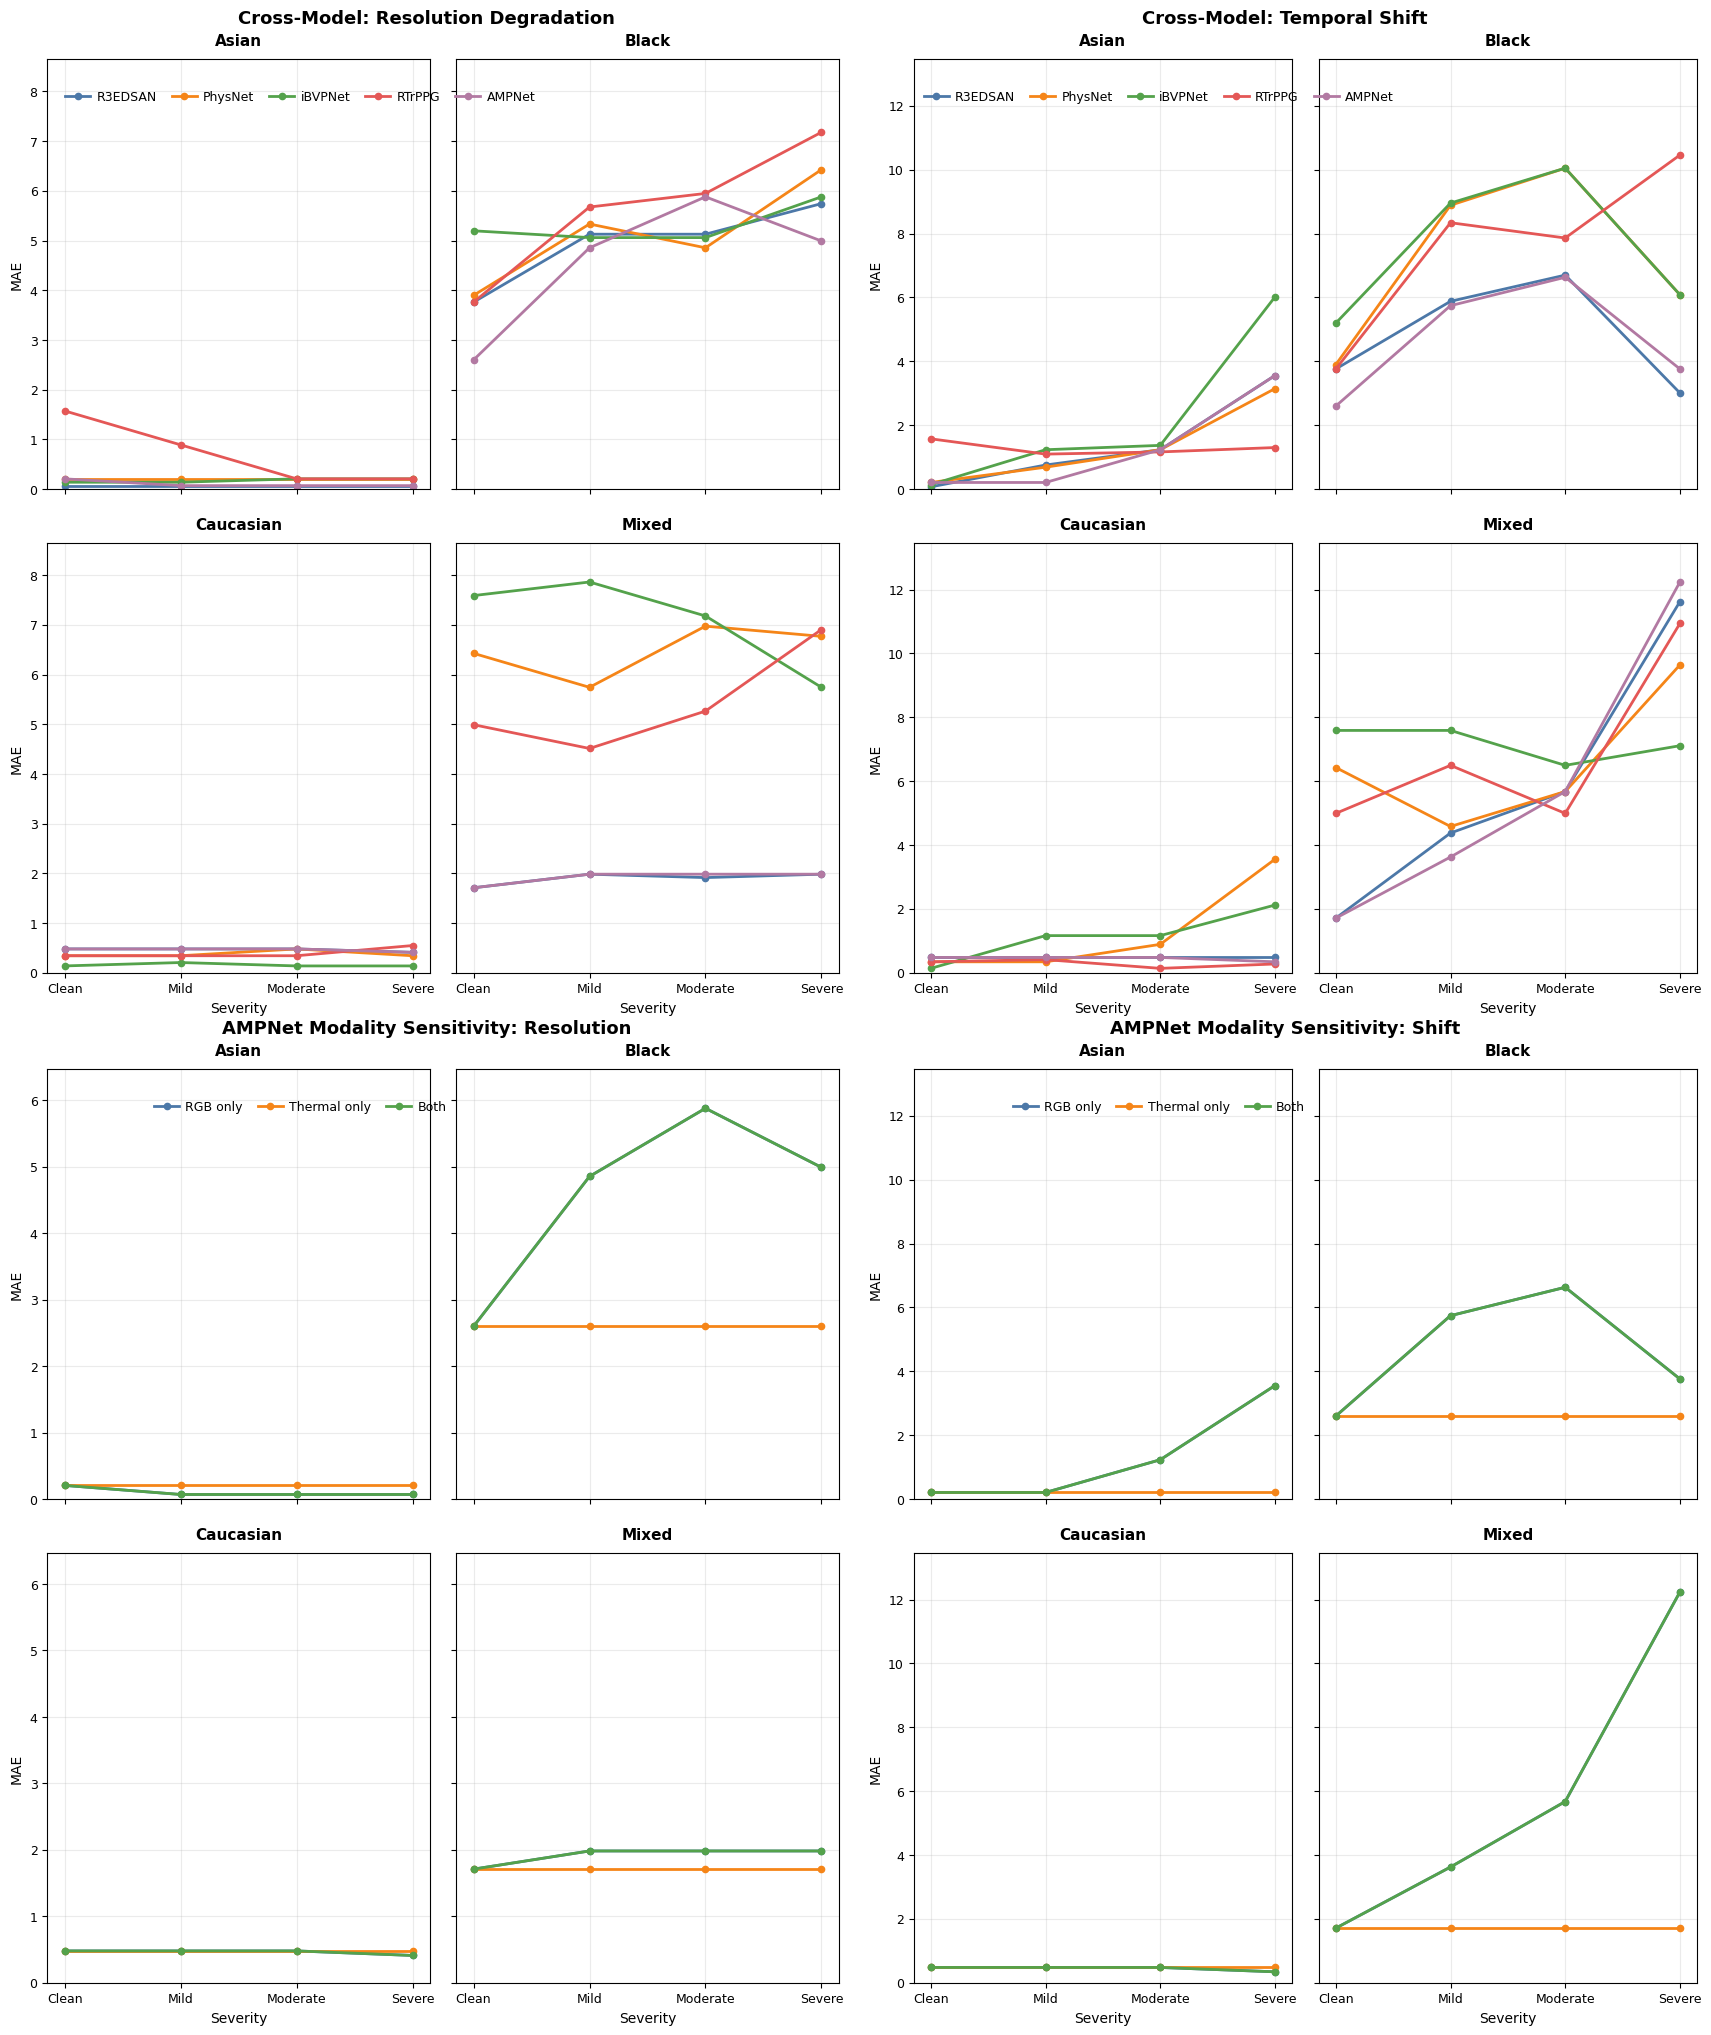

In [28]:
import os
import numpy as np
import matplotlib.pyplot as plt

SAVE_DIR = "robustness_figures"
os.makedirs(SAVE_DIR, exist_ok=True)

SEVERITIES = ["Clean", "Mild", "Moderate", "Severe"]
DEMOGRAPHIES = ["Asian", "Black", "Caucasian", "Mixed"]
MODELS = ["R3EDSAN", "PhysNet", "iBVPNet", "RTrPPG", "AMPNet"]

LINE_STYLES = {
    "RGB only": "-",
    "Thermal only": "--",
    "Both": ":",
}

# ============================================================
# RESULTS
# ============================================================

resolution_results = {
    "Asian": {
        "R3EDSAN": [0.068359375, 0.068359375, 0.068359375, 0.068359375],
        "PhysNet": [0.205078125, 0.205078125, 0.205078125, 0.205078125],
        "iBVPNet": [0.13671875, 0.13671875, 0.205078125, 0.205078125],
        "RTrPPG": [1.572265625, 0.888671875, 0.205078125, 0.205078125],
        "AMPNet": [0.205078125, 0.068359375, 0.068359375, 0.068359375],
    },
    "Black": {
        "R3EDSAN": [3.759765625, 5.126953125, 5.126953125, 5.7421875],
        "PhysNet": [3.896484375, 5.33203125, 4.853515625, 6.42578125],
        "iBVPNet": [5.1953125, 5.05859375, 5.05859375, 5.87890625],
        "RTrPPG": [3.759765625, 5.673828125, 5.947265625, 7.177734375],
        "AMPNet": [2.59765625, 4.853515625, 5.87890625, 4.990234375],
    },
    "Caucasian": {
        "R3EDSAN": [0.478515625, 0.478515625, 0.478515625, 0.41015625],
        "PhysNet": [0.341796875, 0.341796875, 0.478515625, 0.341796875],
        "iBVPNet": [0.13671875, 0.205078125, 0.13671875, 0.13671875],
        "RTrPPG": [0.341796875, 0.341796875, 0.341796875, 0.546875],
        "AMPNet": [0.478515625, 0.478515625, 0.478515625, 0.41015625],
    },
    "Mixed": {
        "R3EDSAN": [1.708984375, 1.982421875, 1.9140625, 1.982421875],
        "PhysNet": [6.42578125, 5.7421875, 6.97265625, 6.767578125],
        "iBVPNet": [7.587890625, 7.861328125, 7.177734375, 5.7421875],
        "RTrPPG": [4.990234375, 4.51171875, 5.263671875, 6.904296875],
        "AMPNet": [1.708984375, 1.982421875, 1.982421875, 1.982421875],
    },
}

shift_results = {
    "Asian": {
        "R3EDSAN": [0.068359375, 0.751953125, 1.23046875, 3.5546875],
        "PhysNet": [0.205078125, 0.68359375, 1.23046875, 3.14453125],
        "iBVPNet": [0.13671875, 1.23046875, 1.3671875, 6.015625],
        "RTrPPG": [1.572265625, 1.09375, 1.162109375, 1.298828125],
        "AMPNet": [0.205078125, 0.205078125, 1.23046875, 3.5546875],
    },
    "Black": {
        "R3EDSAN": [3.759765625, 5.87890625, 6.69921875, 3.0078125],
        "PhysNet": [3.896484375, 8.88671875, 10.048828125, 6.083984375],
        "iBVPNet": [5.1953125, 8.955078125, 10.048828125, 6.083984375],
        "RTrPPG": [3.759765625, 8.33984375, 7.861328125, 10.458984375],
        "AMPNet": [2.59765625, 5.7421875, 6.630859375, 3.759765625],
    },
    "Caucasian": {
        "R3EDSAN": [0.478515625, 0.478515625, 0.478515625, 0.478515625],
        "PhysNet": [0.341796875, 0.341796875, 0.888671875, 3.5546875],
        "iBVPNet": [0.13671875, 1.162109375, 1.162109375, 2.119140625],
        "RTrPPG": [0.341796875, 0.41015625, 0.13671875, 0.2734375],
        "AMPNet": [0.478515625, 0.478515625, 0.478515625, 0.341796875],
    },
    "Mixed": {
        "R3EDSAN": [1.708984375, 4.375, 5.673828125, 11.62109375],
        "PhysNet": [6.42578125, 4.580078125, 5.673828125, 9.638671875],
        "iBVPNet": [7.587890625, 7.587890625, 6.494140625, 7.109375],
        "RTrPPG": [4.990234375, 6.494140625, 4.990234375, 10.9375],
        "AMPNet": [1.708984375, 3.623046875, 5.673828125, 12.236328125],
    },
}

ampnet_resolution_modality = {
    "Asian": {
        "RGB only":     [0.205078125, 0.068359375, 0.068359375, 0.068359375],
        "Thermal only": [0.205078125, 0.205078125, 0.205078125, 0.205078125],
        "Both":         [0.205078125, 0.068359375, 0.068359375, 0.068359375],
    },
    "Black": {
        "RGB only":     [2.59765625, 4.853515625, 5.87890625, 4.990234375],
        "Thermal only": [2.59765625, 2.59765625, 2.59765625, 2.59765625],
        "Both":         [2.59765625, 4.853515625, 5.87890625, 4.990234375],
    },
    "Caucasian": {
        "RGB only":     [0.478515625, 0.478515625, 0.478515625, 0.41015625],
        "Thermal only": [0.478515625, 0.478515625, 0.478515625, 0.478515625],
        "Both":         [0.478515625, 0.478515625, 0.478515625, 0.41015625],
    },
    "Mixed": {
        "RGB only":     [1.708984375, 1.982421875, 1.982421875, 1.982421875],
        "Thermal only": [1.708984375, 1.708984375, 1.708984375, 1.708984375],
        "Both":         [1.708984375, 1.982421875, 1.982421875, 1.982421875],
    },
}

ampnet_shift_modality = {
    "Asian": {
        "RGB only":     [0.205078125, 0.205078125, 1.23046875, 3.5546875],
        "Thermal only": [0.205078125, 0.205078125, 0.205078125, 0.205078125],
        "Both":         [0.205078125, 0.205078125, 1.23046875, 3.5546875],
    },
    "Black": {
        "RGB only":     [2.59765625, 5.7421875, 6.630859375, 3.759765625],
        "Thermal only": [2.59765625, 2.59765625, 2.59765625, 2.59765625],
        "Both":         [2.59765625, 5.7421875, 6.630859375, 3.759765625],
    },
    "Caucasian": {
        "RGB only":     [0.478515625, 0.478515625, 0.478515625, 0.341796875],
        "Thermal only": [0.478515625, 0.478515625, 0.478515625, 0.478515625],
        "Both":         [0.478515625, 0.478515625, 0.478515625, 0.341796875],
    },
    "Mixed": {
        "RGB only":     [1.708984375, 3.623046875, 5.673828125, 12.236328125],
        "Thermal only": [1.708984375, 1.708984375, 1.708984375, 1.708984375],
        "Both":         [1.708984375, 3.623046875, 5.673828125, 12.236328125],
    },
}

MODEL_COLORS = {
    "R3EDSAN": "#4C78A8",
    "PhysNet": "#F58518",
    "iBVPNet": "#54A24B",
    "RTrPPG": "#E45756",
    "AMPNet": "#B279A2",
}

MODALITY_COLORS = {
    "RGB only": "#4C78A8",
    "Thermal only": "#F58518",
    "Both": "#54A24B",
}


def save_figure(fig, filename):
    path = os.path.join(SAVE_DIR, filename)
    fig.savefig(path, dpi=300, bbox_inches="tight")
    print(f"Saved: {path}")


def max_from_nested(results_dict):
    vals = []
    for outer in results_dict.values():
        for inner in outer.values():
            vals.extend(inner)
    return max(vals)


def plot_block(fig, subfig, results_dict, line_colors, line_labels, block_title, y_max):
    axes = subfig.subplots(2, 2, sharex=True, sharey=True)
    axes = axes.flatten()

    for i, demo in enumerate(DEMOGRAPHIES):
        ax = axes[i]
        for label in line_labels:
            values = results_dict[demo][label]
            ax.plot(
                SEVERITIES,
                values,
                marker="o",
                linewidth=2.0,
                markersize=4.5,
                color=line_colors[label],
                label=label,
            )

        ax.set_title(demo, fontsize=11, fontweight="bold", pad=10)
        ax.set_ylim(0, y_max)
        ax.grid(alpha=0.25)
        ax.tick_params(axis="x", labelsize=9)
        ax.tick_params(axis="y", labelsize=9)

        if i % 2 == 0:
            ax.set_ylabel("MAE", fontsize=10)
        if i >= 2:
            ax.set_xlabel("Severity", fontsize=10)

    subfig.suptitle(block_title, fontsize=13, fontweight="bold", y=1.02)

    handles, labels = axes[0].get_legend_handles_labels()
    subfig.legend(
        handles,
        labels,
        loc="upper center",
        ncol=len(line_labels),
        frameon=False,
        fontsize=9,
        bbox_to_anchor=(0.35, 0.95),
        columnspacing=1.2,
        handletextpad=0.5,
    )


def main():
    plt.rcParams.update({
        "font.size": 9,
        "axes.titlesize": 11,
        "axes.labelsize": 10,
        "legend.fontsize": 9,
    })

    fig = plt.figure(figsize=(17, 20), constrained_layout=True)
    subfigs = fig.subfigures(2, 2)

    y1 = max_from_nested(resolution_results) * 1.10
    plot_block(
        fig,
        subfigs[0, 0],
        resolution_results,
        MODEL_COLORS,
        MODELS,
        "Cross-Model: Resolution Degradation",
        y1,
    )

    y2 = max_from_nested(shift_results) * 1.10
    plot_block(
        fig,
        subfigs[0, 1],
        shift_results,
        MODEL_COLORS,
        MODELS,
        "Cross-Model: Temporal Shift",
        y2,
    )

    y3 = max_from_nested(ampnet_resolution_modality) * 1.10
    plot_block(
        fig,
        subfigs[1, 0],
        ampnet_resolution_modality,
        MODALITY_COLORS,
        ["RGB only", "Thermal only", "Both"],
        "AMPNet Modality Sensitivity: Resolution",
        y3,
    )

    y4 = max_from_nested(ampnet_shift_modality) * 1.10
    plot_block(
        fig,
        subfigs[1, 1],
        ampnet_shift_modality,
        MODALITY_COLORS,
        ["RGB only", "Thermal only", "Both"],
        "AMPNet Modality Sensitivity: Shift",
        y4,
    )

    """    fig.suptitle(
            "Robustness Analysis Across Perturbations, Demographics, and Models",
            fontsize=15,
            fontweight="bold",
            y=1.01
        )"""

    save_figure(fig, "figure_all_in_one_robustness.png")
    plt.show()


if __name__ == "__main__":
    main()